# [01 EDA — Hospital Length of Stay]


**Task:** to predict `lengthofstay` (a simplified proxy for healthcare use cost of a patient) — a **regression** problem.  

**Dataset:** Microsoft LOS (available on Kaggle), 100k rows × 28 columns.  
**Objective of this notebook:** understand the data to define feature engineering, a modelling baseline, and the prospective monitoring setup.

Main focus:   
-- the target's shape + a baseline error to beat;   
-- confirmation & removal of the date leakage;    
-- a clean feature   list with correct dtypes/encodings;   
-- the top features associated with LOS;   
-- any data-quality fixes needed.   

> Column reference: https://microsoft.github.io/r-server-hospital-length-of-stay/input_data.html

## 0. Setup & load

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

pd.set_option("display.max_columns", None)

# Read the CSV data
df = pd.read_csv("../data/LengthOfStay.csv")
print(df.shape)
df.head()

## df.shape
## (100000, 28)

(100000, 28)


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


## 1. Target `lengthofstay`

Everything hinges on the target's shape (right-skewed count, capped at 17).

- What's the distribution? Skewed? Is 17 a hard ceiling (censoring)?
- What baseline must a model beat? "Always predict the mean/median" sets the error floor.

In [ ]:
display(df["lengthofstay"].describe())
df["lengthofstay"].value_counts().sort_index()


# count    100000.00000
# mean          4.00103
# std           2.36031
# min           1.00000
# 25%           2.00000
# 50%           4.00000
# 75%           6.00000
# max          17.00000

count    100000.00000
mean          4.00103
std           2.36031
min           1.00000
25%           2.00000
50%           4.00000
75%           6.00000
max          17.00000
Name: lengthofstay, dtype: float64

lengthofstay
1     17979
2     12825
3     16068
4     14822
5     12116
6     10362
7      7263
8      4652
9      2184
10     1000
11      460
12      137
13       75
14       31
15       16
16        6
17        4
Name: count, dtype: int64

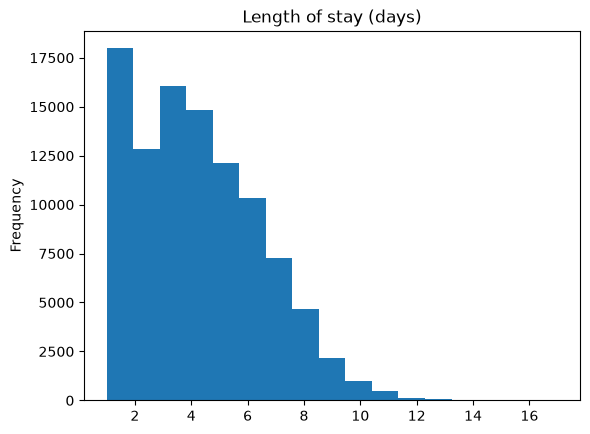

In [9]:
df["lengthofstay"].plot(kind="hist", bins=17, title="Length of stay (days)");

In [10]:
# Naive baselines: the error to beat. (MAE = mean absolute error, RMSE = root mean squared error.)
import numpy as np

y = df["lengthofstay"]
for name, pred in {"mean": y.mean(), "median": y.median()}.items():
    mae = (y - pred).abs().mean()
    rmse = np.sqrt(((y - pred) ** 2).mean())
    print(f"predict {name}={pred:.2f}  ->  MAE={mae:.3f}  RMSE={rmse:.3f}")

predict mean=4.00  ->  MAE=1.914  RMSE=2.360
predict median=4.00  ->  MAE=1.914  RMSE=2.360


## 2. Leakage check

`vdate` (admission) and `discharged` are dates;    

`discharged - vdate` reproduces `lengthofstay` almost exactly. That is the answer leaking in.    
To **drop `vdate`, `discharged`, `eid` from the features**.

Keep `vdate` around *only* for building temporal splits later (Phase 1 monthly batches) — never as a model input.

In [20]:
d = pd.to_datetime(df["discharged"]) - pd.to_datetime(df["vdate"])
# Expect almost all zeros -> discharged-vdate == lengthofstay (leakage confirmed).
(d.dt.days - df["lengthofstay"]).value_counts()

0    100000
Name: count, dtype: int64

## 3 · Data quality — dtypes, missingness, encodings

The data dictionary says the comorbidity flags load as strings and `rcount` contains a `"5+"` value, so several "numeric" columns won't arrive as numbers.

- True dtype of each column?  
- Any missing values?  
- How are the flags encoded (0/1, Y/N, ...)?  
- `rcount` — confirm the `"5+"` string.  
- `gender` — M/F.  
- `facid` — an **ID**, treat as categorical, not a quantity.

In [73]:
## First, check if there are any duplicate rows in the dataset. 
## >> No duplicate rows 
display(df["eid"].nunique() == len(df))
display(df.duplicated().sum())

True

np.int64(0)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  str    
 2   rcount                      100000 non-null  str    
 3   gender                      100000 non-null  str    
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition              

In [74]:
df.isna().sum()

eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
creatinine                    0
bmi                           0
pulse                         0
respiration                   0
secondarydiagnosisnonicd9     0
discharged                    0
facid                         0
lengthofstay                  0
comorbidity_count             0
dtype: int64

In [23]:
# Inspect the encodings of the categorical / flag-like columns.
for col in ["gender", "rcount", "facid", "secondarydiagnosisnonicd9", "asthma"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- gender ---
gender
F    57643
M    42357
Name: count, dtype: int64

--- rcount ---
rcount
0     55031
1     15007
2      9987
3      8047
4      6941
5+     4987
Name: count, dtype: int64

--- facid ---
facid
E    30755
A    30035
B    30012
C     4699
D     4499
Name: count, dtype: int64

--- secondarydiagnosisnonicd9 ---
secondarydiagnosisnonicd9
1     50029
0     10090
2      9782
3      9020
4      8990
5      3987
6      3086
7      1960
10     1049
8      1006
9      1001
Name: count, dtype: int64

--- asthma ---
asthma
0    96473
1     3527
Name: count, dtype: int64



## 4 · Feature ↔ target relationships

What actually drives LOS? Correlations for continuous features; grouped mean LOS for flags/categoricals; and the plan's suggested engineered feature — total comorbidity burden.

In [61]:
# Engineered feature: total comorbidity burden = sum of the 11 flags.
flags = [
    "dialysisrenalendstage", "asthma", "irondef", "pneum", "substancedependence",
    "psychologicaldisordermajor", "depress", "psychother", "fibrosisandother",
    "malnutrition", "hemo",
]

df["comorbidity_count"] = df[flags].apply(pd.to_numeric, errors="coerce").sum(axis = 1)
df.groupby("comorbidity_count")["lengthofstay"].agg(["mean", "count"])


,mean,count
comorbidity_count,,
0,3.108910,57341
1,4.985096,23350
2,5.145198,11536
3,5.303648,4660
4,6.740337,2018
5,6.921087,773
6,7.287356,261
7,8.000000,46
8,9.416667,12


In [ ]:
# Correlation of numeric features with the target (labs, vitals, counts).
# Except 'eid'
df.corr(numeric_only=True).loc[:, "lengthofstay"].drop("eid", errors="ignore").sort_values(ascending =False)

lengthofstay                  1.000000
comorbidity_count             0.417276
psychologicaldisordermajor    0.286724
hemo                          0.217696
irondef                       0.193838
psychother                    0.191695
malnutrition                  0.174397
dialysisrenalendstage         0.169695
bloodureanitro                0.148290
substancedependence           0.147886
pneum                         0.135461
depress                       0.121408
asthma                        0.082005
fibrosisandother              0.062131
pulse                         0.006683
secondarydiagnosisnonicd9     0.006540
bmi                           0.000132
glucose                      -0.003447
sodium                       -0.003546
creatinine                   -0.004026
neutrophils                  -0.010658
respiration                  -0.022291
hematocrit                   -0.064016
Name: lengthofstay, dtype: float64

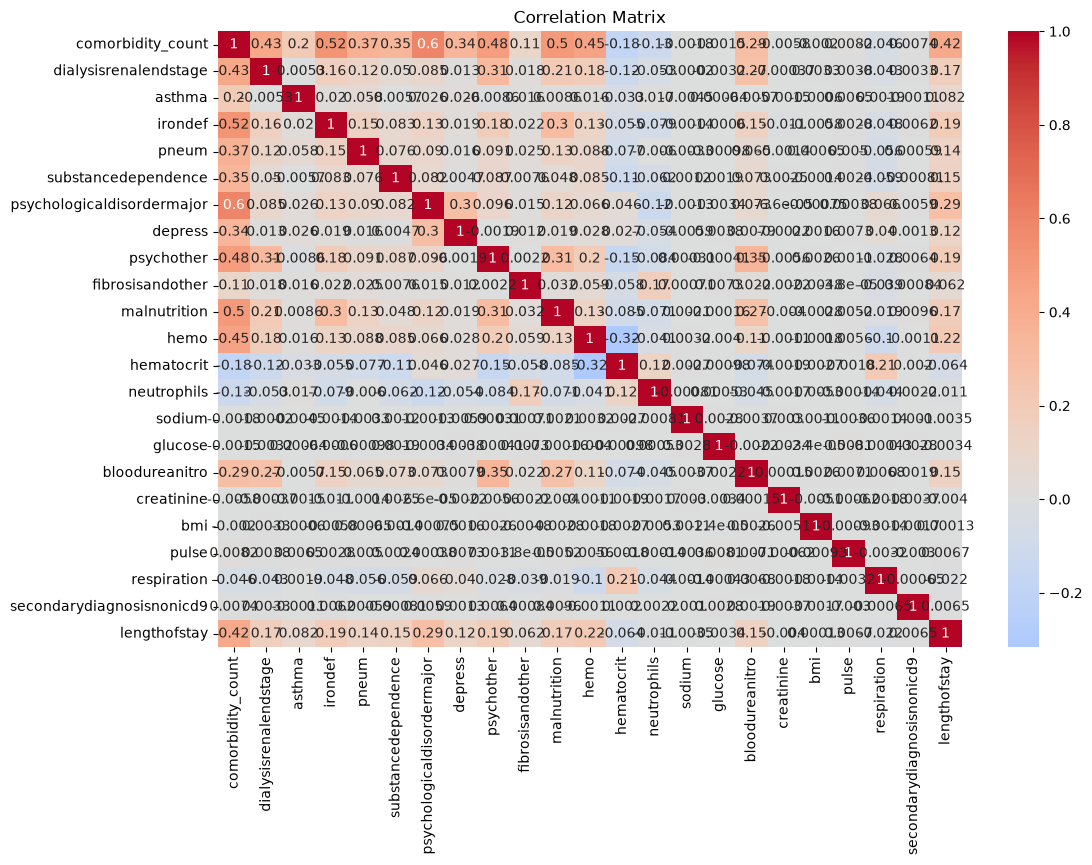

In [63]:
# Create a heatmap as well to check the correlation between the features and the target and also among the features per se

df2 = df.drop(columns=["eid"], errors="ignore")
df2.insert(0, "comorbidity_count", df2.pop("comorbidity_count"))
num_corr = df2.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(num_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Does mean LOS differ by group? (repeat for rcount, gender, facid, ...)
df.groupby("gender")["lengthofstay"].agg(["mean", "count"])

,mean,count
gender,,
F,3.860261,57643
M,4.192601,42357


In [ ]:
# Does mean LOS differ by diferent rcount (Number of readmissions within last 180 days)? 
## There is a clear trend of increasing LOS with increasing rcount, which is expected.
display(df.groupby("rcount")["lengthofstay"].agg(["mean", "count"]))


,mean,count
rcount,,
0,2.722048,55031
1,3.697141,15007
2,5.270452,9987
3,6.272772,8047
4,7.257888,6941
5+,8.288149,4987


In [68]:
# Does mean LOS differ by different secondarydiagnosisnonicd9 (Secondary diagnosis)?
## Doens't seem to be a clear trend
display(df.groupby("secondarydiagnosisnonicd9")["lengthofstay"].agg(["mean", "count"]))


,mean,count
secondarydiagnosisnonicd9,,
0,3.993558,10090
1,3.990106,50029
2,3.992231,9782
3,4.015965,9020
4,4.022247,8990
5,3.996739,3987
6,4.033701,3086
7,4.123469,1960
8,4.025845,1006


## 5 · Distributions & outliers in labs / vitals

Labs and vitals have physiologically plausible ranges. Values outside them (e.g. BMI of 0, pulse of 0) are likely errors and need handling. Check spread and skew.

In [40]:
labs_vitals = [
    "hematocrit", "neutrophils", "sodium", "glucose", "bloodureanitro",
    "creatinine", "bmi", "pulse", "respiration",
]

df[labs_vitals].describe()


,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,11.975939,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768
std,2.031792,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473
min,4.400000,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000
25%,10.900000,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000
50%,11.900000,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000
75%,12.900000,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000
max,24.100000,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000


In [65]:
display(df[labs_vitals].quantile(0.99))


hematocrit         18.200000
neutrophils        25.000000
sodium            144.857665
glucose           211.156559
bloodureanitro     53.000000
creatinine          1.564592
bmi                34.454720
pulse             101.000000
respiration         8.200000
Name: 0.99, dtype: float64

`glucose` min = −1.006 → a negative glucose is physiologically impossible.   

`neutrophils` max = 245.9 (mean ≈ 10, 99pct = 25) and `bloodureanitro` max = 682.5 (75th pct = 14, 99pct = 53) → extreme outliers, almost certainly errors or units glitches.     

`respiration`: 25th = 50th = 75th percentile = 6.5 → the column is almost constant. Very low variance = barely any predictive signal.  

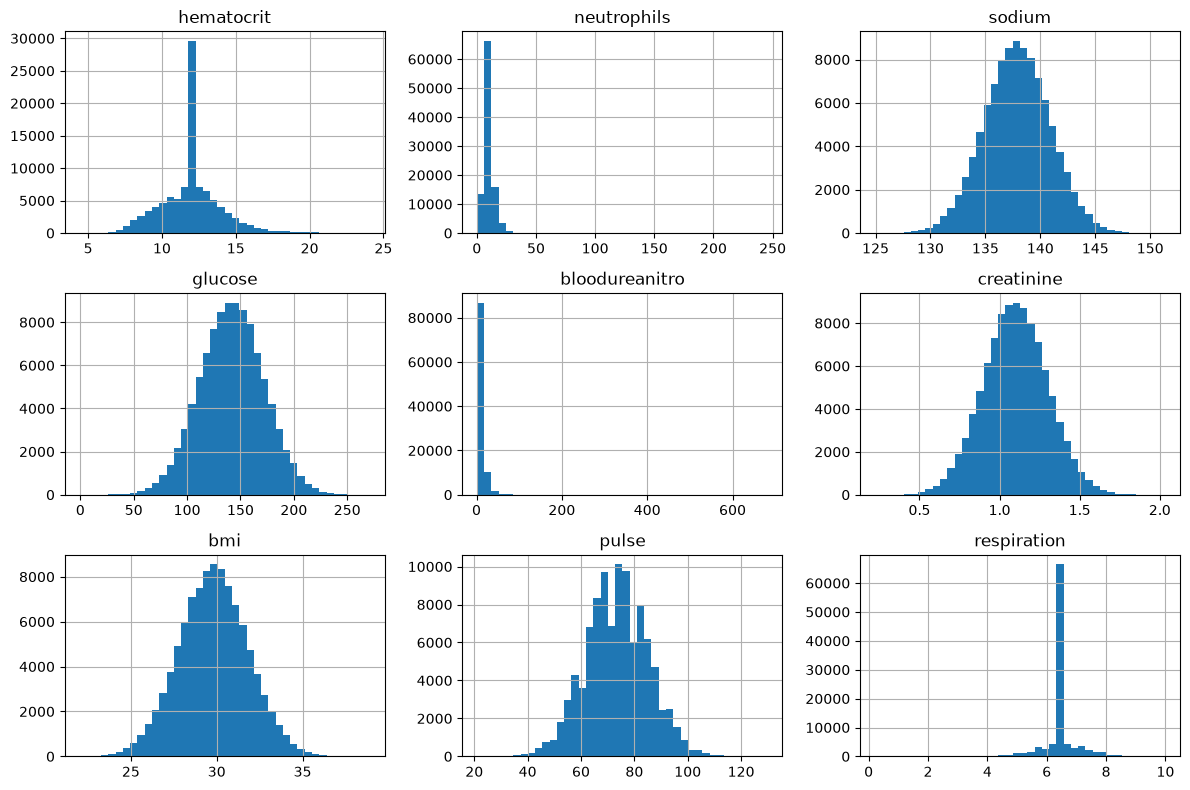

In [30]:
df[labs_vitals].hist(figsize=(12, 8), bins=40)
import matplotlib.pyplot as plt
plt.tight_layout();

## 6 · Drift angle (Phase 1 setup)

Phase 1 is monitoring/drift. The features to watch month-to-month — continuous labs/vitals may be the natural drift candidates; `rcount` / comorbidity mix capture population change. Use `vdate` to slice into monthly batches (this is the ONLY place `vdate` is used).

The data spans across 12 clean months of ~8k plus a stub 2013-01 with only 263 rows 
>> may consider merge that single date (2013-01-01) into the last month when building monthly batches in Phase 1

In [43]:
# Peek at the admission date range and monthly volume (for future temporal splits).
vdate = pd.to_datetime(df["vdate"])
print(vdate.min(), "->", vdate.max())
vdate.dt.to_period("M").value_counts().sort_index()

2012-01-01 00:00:00 -> 2013-01-01 00:00:00


vdate
2012-01    8337
2012-02    8011
2012-03    8442
2012-04    7940
2012-05    8482
2012-06    8226
2012-07    8323
2012-08    8478
2012-09    8242
2012-10    8566
2012-11    8298
2012-12    8392
2013-01     263
Freq: M, Name: count, dtype: int64

## 7 · Findings summary   

_What the target looks like, the baseline error to beat, leakage confirmed & columns to drop, encodings/dtype fixes needed, and the strongest features. This becomes the spec for feature engineering and your first pytest tests._

- **Target:** `lengthofstay`   
>> right-skewed integer count, 1–17, mean 4, std 2.36  

- **Baseline to beat:**    
>> mean=4.00  ->  MAE=1.914  RMSE=2.360      
>> median=4.00  ->  MAE=1.914  RMSE=2.360   


- **Leakage / drop:**   
`discharged` and `vdate` are both [date] types. A raw date isn't directly useful usually.   
discharged - vdate == lengthofstay, in all instances    
discharged contains information from the future --> it's the leak.    
Both should be dropped



- **Dtype & encoding fixes:**    
The columns/variables that might need converting:    
>> * `gender`: M/F → isMale (1/0)  
>> * flags: already int64 (0/1)
>> * `rcount`: map "5+" → 5 (ordinal numeric)  
>> * `facid`: treat as categorical, one-hot encode (not raw int)  
>> * drop `vdate`, `discharged`, `eid`  

- **Strongest features:**  
    LOS appears to be driven almost entirely by [comorbidity] flags (e.g. `psychologicaldisordermajor` and `hemo`) + `rcount` + `comorbidity_count`. 

    Most biomarkers are essentially uncorrelated with LOS: bmi 0.0001, glucose −0.003, creatinine −0.004, pulse 0.007 

    `secondarydiagnosisnonicd9` seems to have extremely low correlation with LOS; it may not matter much

    >> Note: .corr measures only linear association. Algorithms like gradient boosting / XGBoost may pick up non-linear effects a Pearson correlation misses. We can assess the contibutions of the variables again with model-based importance (SHAP) later

 

- **Data-quality issues:** 
There are no missing records for any of the variables.   

1. However, a few issues are flagged up with several biomarkers.   
    `glucose` min = −1.006 → a negative glucose is physiologically impossible 
    >> apply clinical plausibility bounds (e.g. glucose > 0)  

    `neutrophils` max = 245.9 (mean ≈ 10, 99pct = 25) and `bloodureanitro` max = 682.5 (75th pct = 14, 99pct = 53) → extreme outliers, almost certainly errors or units glitches.       
    >> * may consider applying a universal criterion to exclude the top 1% values of the biomarker measurements or capping/winsorizing     
    >> * Remember to fit on the training split only (else it leaks test info)   

    `respiration`: 25th = 50th = 75th percentile = 6.5 → the column is almost constant. Very low variance = barely any predictive signal.      
    >> may consider dropping this variable  

2. `secondarydiagnosisnonicd9`'s correlation with LOS is ~0; it may not matter much

## 8 · Decisions → feature engineering / splits

_Carried forward from the findings above. This is the spec for `02_feature_engineering.ipynb`, the temporal splits, and the first pytest tests._

### Columns to drop (not model features)
- `eid` — row identifier, no signal.
- `discharged` — **leakage**: future information (unknown at admission); `discharged - vdate == lengthofstay` in 100% of rows.
- `vdate` — not useful as a raw date feature, **but keep it until after splitting**: it is the basis for the temporal batches (below). Drop it only from the *feature matrix*, not from the working frame.
- `secondarydiagnosisnonicd9` — ranges 0–10, so a *count* of secondary diagnoses, not a flag; mean LOS is flat across its values and corr ≈ 0. low priority.

### Encoding / dtype fixes
- Comorbidity flags (11) — **already `int64` 0/1, no conversion needed.**
- `gender` — map to a single binary `isMale` (1/0). Binary → one column, not one-hot.
- `rcount` — map `"5+"` → `5`, treat as numeric/ordinal.
- `facid` — categorical (currently `str`, 5 levels) → **one-hot encode**; the label has no order.

- Engineered feature: `comorbidity_count` = sum of the 11 flags (strongest single correlate, r ≈ 0.42).

### Data-quality fixes — fit on the TRAIN split only (avoid leakage)
- `glucose` — impossible negative min (−1.0). Apply a **clinical plausibility bound** (glucose > 0).
- `neutrophils` (max 246) and `bloodureanitro` (max 682) — extreme right-tail outliers. **Winsorize / cap** rather than drop rows (dropping each column's top 1% deletes many rows and some values may be real). Trees are fairly robust to feature outliers, so this is mostly a *validity* fix.
- `respiration` — near-constant (IQR all = 6.5), negligible variance → candidate to **drop** (little signal).

### Target treatment — right-skewed count (1–17, mean 4, std 2.36)
- Skew is **moderate, not extreme** — measure, don't over-engineer. Trees handle *feature* skew; the *target* skew is a modelling **choice** made via the objective/transform, not something XGBoost fixes automatically.
- **A/B in MLflow (Phase 2):** (a) `reg:squarederror`, (b) `log1p(target)` + back-transform `expm1`, (c) `count:poisson` / `reg:tweedie` (natural for a positive count). Compare **MAE (headline)** and RMSE against the naive baseline (MAE 1.914).
- **Clip predictions at the floor (≥ 1)** — removes impossible sub-1 / negative outputs (esp. linear models or `log1p` back-transform).
- **The upper bound (17) is a dataset artifact, not biology.** The target tapers smoothly (no spike at 17 → observed max, not hard censoring); tree ensembles can't predict above their training max anyway, so an upper clip is largely redundant. **Do not treat 17 as a real ceiling** — the model will under-serve genuinely long stays. Record this as a known limitation (a Phase-1 monitoring signal; a Phase-5 clinical-write-up caveat; conceptually this is right-censoring).

### Splits
- **Temporal, not random**: train on earlier months → test on later months (mirrors deployment — predict the future from the past). A random split would leak future information.
- **Batches = 12 months of 2012.** The `2013-01` stub is a single boundary day (2013-01-01, 263 rows) → **merge it into 2012-12** by relabelling its `batch_month` (keep the raw `vdate` intact). December then ≈ 8,655, in line with the other months.

  ```python
  month = pd.to_datetime(df["vdate"]).dt.to_period("M")
  month = month.where(month < "2013-01", pd.Period("2012-12", freq="M"))
  df["batch_month"] = month
  ```
- These monthly batches double as the **simulated production batches** for Evidently drift/performance monitoring (Phase 1).

### First pytest tests (Phase 1 "≥2 tests before advancing")
- No leakage: assert `eid`, `vdate`, `discharged` are absent from the feature matrix.
- No stub batch: `df["batch_month"].value_counts().min() > 1000`.
- Feature-engineering sanity: `comorbidity_count` ∈ [0, 11] with no NaN; `rcount` fully numeric after the `"5+"` mapping.
